# Lecture 2. Convexity: from sets to functions

**Convex optimization, Fall 2026**

Lecture 1 used one sentence as a promise: on a convex problem, a local minimum is global and you can certify it. Today we build the objects that sentence is about.

> A set is convex when it contains every segment. A function is convex when the set *above its graph* is.

Everything else is a way to avoid checking that definition by hand:

- criteria, so a formula can be checked;
- constructions, so a model can be built from pieces;
- DCP, so a parser can check the pieces for you.


## Plan

1. Convex sets — the segment, the hull, the sets we will actually use
2. Operations that preserve convexity of sets
3. Convex functions — the chord, and the epigraph that ties functions back to sets
4. Convexity criteria — lines, tangents, Hessians, subgradients
5. How to construct convex functions without opening the definition
6. What DCP is — a grammar, not a convexity test
7. Modeling: ellipsoidal robust constraints, nuclear-norm completion

Notation is lecture 1's. Vectors and matrices are bold. $f'(\mathbf{x})$ is the gradient.


In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

rng = np.random.default_rng(0)
plt.rcParams.update(
    {
        "figure.figsize": (7.2, 4.0),
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 11,
    }
)


# 1. Convex sets

A constraint set you can optimize over, in this course, is a convex set. The definition is one line. The rest of the section is learning to see it.


## The segment

$C\subseteq\mathbb{R}^n$ is **convex** if for every $\mathbf{x},\mathbf{y}\in C$ and every $\theta\in[0,1]$,

$$
\theta\mathbf{x}+(1-\theta)\mathbf{y}\in C.
$$

The same rule with $k$ points is a **convex combination**

$$
\sum_{i=1}^k \theta_i \mathbf{x}_i,\qquad \theta_i\ge 0,\quad \sum_{i=1}^k\theta_i=1.
$$

- A convex set contains every convex combination of its points, not only its segments.
- The $k=2$ definition already implies the rest, by induction.


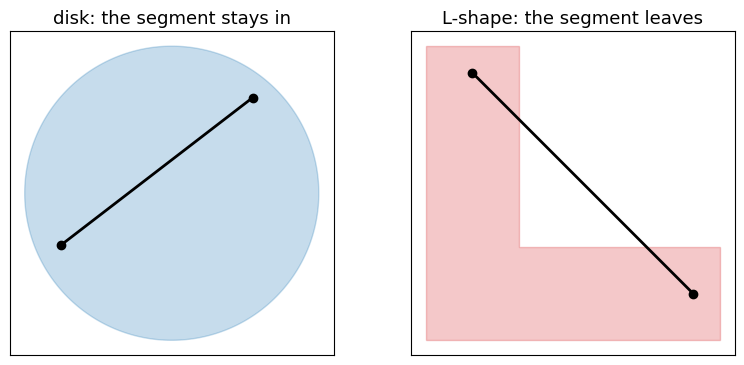

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))

theta = np.linspace(0, 2 * np.pi, 300)
axes[0].fill(np.cos(theta), np.sin(theta), color="C0", alpha=0.25)
a, b = np.array([-0.75, -0.35]), np.array([0.55, 0.65])
axes[0].plot([a[0], b[0]], [a[1], b[1]], color="k", lw=2)
axes[0].scatter([a[0], b[0]], [a[1], b[1]], color="k", zorder=3)
axes[0].set_title("disk: the segment stays in")
axes[0].set_aspect("equal")

# L-shape: a chord between the two arms leaves the set
L = np.array([[0, 0], [2.2, 0], [2.2, 0.7], [0.7, 0.7], [0.7, 2.2], [0, 2.2]])
axes[1].fill(L[:, 0], L[:, 1], color="C3", alpha=0.25)
p, q = np.array([2.0, 0.35]), np.array([0.35, 2.0])
axes[1].plot([p[0], q[0]], [p[1], q[1]], color="k", lw=2)
axes[1].scatter([p[0], q[0]], [p[1], q[1]], color="k", zorder=3)
axes[1].set_title("L-shape: the segment leaves")
axes[1].set_aspect("equal")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()


## Convex hull

The **convex hull** $\mathrm{conv}(S)$ is the set of all finite convex combinations of points of $S$. Two equivalent pictures:

- intersect every convex set that contains $S$ — the smallest one;
- start from $S$ and close it under segments.

**Carathéodory.** In $\mathbb{R}^n$:

- every point of $\mathrm{conv}(S)$ is a convex combination of at most $n+1$ points of $S$;
- you never need a longer combination than the ambient dimension plus one;
- the simplex $\Delta^{n-1}$ is the extreme case: $n$ vertices, affine dimension $n-1$.


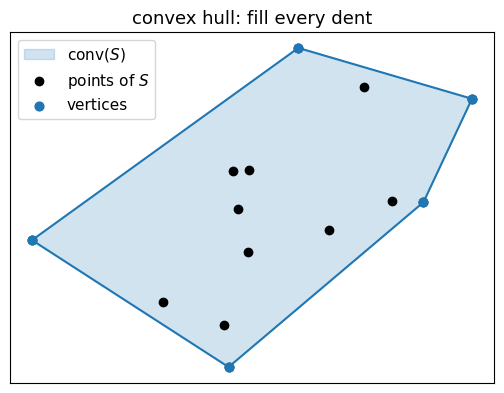

In [3]:
pts = rng.normal(size=(14, 2))
hull = ConvexHull(pts)
order = np.append(hull.vertices, hull.vertices[0])

fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.fill(pts[order, 0], pts[order, 1], color="C0", alpha=0.2, label=r"$\mathrm{conv}(S)$")
ax.plot(pts[order, 0], pts[order, 1], color="C0")
ax.scatter(pts[:, 0], pts[:, 1], color="k", zorder=3, label="points of $S$")
ax.scatter(pts[hull.vertices, 0], pts[hull.vertices, 1], color="C0", s=40, zorder=4, label="vertices")
ax.set_aspect("equal")
ax.set_title("convex hull: fill every dent")
ax.legend(loc="best")
ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()
plt.show()


## The sets we will actually use

| Set | Definition | Why it is convex |
|---|---|---|
| Affine subspace | $\{\mathbf{x}:\mathbf{A}\mathbf{x}=\mathbf{b}\}$ | the combination preserves equalities |
| Halfspace | $\{\mathbf{x}:\mathbf{a}^\top\mathbf{x}\le b\}$ | the combination preserves one inequality |
| Norm ball | $\{\mathbf{x}:\Vert \mathbf{x}\Vert \le 1\}$ | triangle inequality |
| Ellipsoid | $\{\mathbf{x}:\Vert\mathbf{A}\mathbf{x}+\mathbf{b}\Vert_2\le 1\}$ | affine image of a ball |
| Polyhedron | $\{\mathbf{x}:\mathbf{A}\mathbf{x}\le\mathbf{b}\}$ | intersection of halfspaces |
| Simplex | $\{\mathbf{x}\ge 0:\mathbf{1}^\top\mathbf{x}=1\}$ | convex combinations of the $\mathbf{e}_i$ |
| Second-order cone | $\{(\mathbf{x},t):\Vert\mathbf{x}\Vert_2\le t\}$ | ice-cream cone; a convex cone |
| PSD cone | $\mathbf{S}^n_+=\{\mathbf{X}:\mathbf{v}^\top\mathbf{X}\mathbf{v}\ge 0\ \forall\mathbf{v}\}$ | $\mathbf{v}^\top(\theta\mathbf{X}+(1-\theta)\mathbf{Y})\mathbf{v}$ stays nonnegative |

A **convex cone** is a convex set closed under positive scaling: $\mathbf{x}\in C$, $\lambda\ge 0$ $\Rightarrow$ $\lambda\mathbf{x}\in C$.

- The orthant, the second-order cone, and $\mathbf{S}^n_+$ are the three cones this course keeps reusing.
- Norms, epigraphs, and dual problems all live next to a cone.


## Almost, but not

These fail the segment test. Each one shows up as a constraint people wish were convex.

- **Integer points** $\mathbb{Z}^n$. The midpoint of $\mathbf{0}$ and $\mathbf{e}_1$ is not integer.
- **A union of two disks**, unless one contains the other. Intersection is safe; union is not.
- **Rank.** $\{\mathbf{X}:\mathrm{rank}(\mathbf{X})\le k\}$ for $k<n$. Average two rank-$1$ matrices on different lines and the rank jumps. This is why matrix completion in section 7 replaces rank by a convex stand-in.
- **A quadratic bowl with the wrong signature.** $\{\mathbf{x}:\mathbf{x}^\top\mathbf{A}\mathbf{x}\le 1\}$ is an ellipsoid when $\mathbf{A}\succ 0$, and a hyperboloid when $\mathbf{A}$ is indefinite. The segment between the two branches leaves the set.


## Why a convex set is a tractable constraint

**Separating hyperplane.** Let $C$ be closed and convex, and let $\mathbf{x}\notin C$. Then there is a nonzero $\mathbf{a}$ and a scalar $b$ with

$$
\mathbf{a}^\top\mathbf{x} > b \ge \mathbf{a}^\top\mathbf{y}\qquad\text{for every }\mathbf{y}\in C.
$$

Consequences:

- a closed convex set is exactly the intersection of the halfspaces that contain it;
- a polyhedron is the case of finitely many halfspaces;
- the PSD cone needs infinitely many, one for each $\mathbf{v}$: $\mathbf{v}^\top\mathbf{X}\mathbf{v}\ge 0$;
- if a point is infeasible, some linear inequality witnesses it.


### References — convex sets

- **Book.** S. Boyd and L. Vandenberghe, [*Convex Optimization*](https://web.stanford.edu/~boyd/cvxbook/), Ch. 2. The catalogue above is theirs.
- **Book.** R. T. Rockafellar, *Convex Analysis* (Princeton, 1970), for convex hulls, cones, and separation with the hypotheses stated carefully.
- **Lectures.** [EE364a](https://web.stanford.edu/class/ee364a/), sets and functions; A. Nemirovski, *Lectures on Modern Convex Optimization*


# 2. Operations that preserve convexity

You almost never test the segment condition on the set you actually optimize over.

- Build the set from pieces you already trust.
- Use only operations that cannot create a dent.


## Intersection, images, preimages

**Intersection.** If every $C_\alpha$ is convex, then $\bigcap_\alpha C_\alpha$ is convex, even if the family is infinite.

- A failed segment in the intersection would already be a failed segment in some $C_\alpha$.

**Affine image.** If $C$ is convex, so is $\{\mathbf{A}\mathbf{x}+\mathbf{b}:\mathbf{x}\in C\}$.

- Projection: $\mathbf{A}$ drops coordinates.
- Scaling and translation: $\mathbf{A}=\lambda\mathbf{I}$.

**Affine preimage.** If $C$ is convex, so is $\{\mathbf{x}:\mathbf{A}\mathbf{x}+\mathbf{b}\in C\}$.

- Slicing by linear equations is the preimage of an affine subspace.
- An ellipsoid is the preimage of the Euclidean ball under an affine map.

Both facts push the segment rule through a map that sends segments to segments. A nonlinear map does not.


## Products and Minkowski sums

**Cartesian product.** $C\times D$ is convex when $C$ and $D$ are.

- Epigraphs, next section, are pieces of a product of the domain with a $t$-axis.

**Minkowski sum.**

$$
C+D=\{\mathbf{x}+\mathbf{y}:\mathbf{x}\in C,\ \mathbf{y}\in D\}.
$$

- The sum of convex sets is convex: add the two segments.
- A disk plus a square is a square with rounded corners.
- Uncertainty sets are often a nominal polyhedron, fattened by a ball of radius $\rho$.


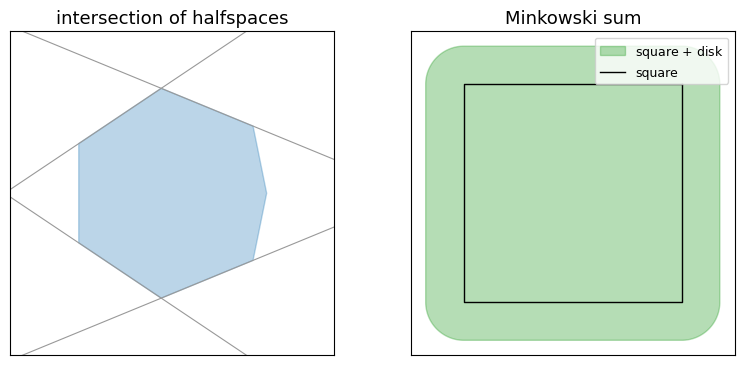

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))

# Intersection of random halfspaces through the origin, shifted out.
angles = np.linspace(0.2, 2 * np.pi - 0.2, 7)
A = np.stack([np.cos(angles), np.sin(angles)], axis=1)
b = 1.15 * np.ones(len(angles))
# Vertex enumeration in 2d: intersections of pairs of lines, keep the feasible ones.
verts = []
for i in range(len(b)):
    for j in range(i + 1, len(b)):
        M = np.stack([A[i], A[j]])
        if abs(np.linalg.det(M)) < 1e-8:
            continue
        v = np.linalg.solve(M, np.array([b[i], b[j]]))
        if np.all(A @ v <= b + 1e-8):
            verts.append(v)
verts = np.array(verts)
order = np.append(ConvexHull(verts).vertices, ConvexHull(verts).vertices[0])
axes[0].fill(verts[order, 0], verts[order, 1], color="C0", alpha=0.3)
xx = np.linspace(-2.2, 2.2, 400)
for i in range(len(b)):
    # a0 x + a1 y = b
    if abs(A[i, 1]) > 0.3:
        yy = (b[i] - A[i, 0] * xx) / A[i, 1]
        axes[0].plot(xx, yy, color="0.6", lw=0.8)
axes[0].set_xlim(-2, 2)
axes[0].set_ylim(-2, 2)
axes[0].set_aspect("equal")
axes[0].set_title("intersection of halfspaces")

# Square [-1, 1]^2 plus a disk of radius 0.35: offset each support point.
dirs = np.linspace(0, 2 * np.pi, 240, endpoint=False)
boundary = []
for phi in dirs:
    u = np.array([np.cos(phi), np.sin(phi)])
    boundary.append(np.sign(u) + 0.35 * u)
boundary = np.array(boundary)
square = np.array([[1, 1], [1, -1], [-1, -1], [-1, 1], [1, 1]])
axes[1].fill(boundary[:, 0], boundary[:, 1], color="C2", alpha=0.35, label="square $+$ disk")
axes[1].plot(square[:, 0], square[:, 1], color="k", lw=1, label="square")
axes[1].set_aspect("equal")
axes[1].set_title("Minkowski sum")
axes[1].legend(loc="upper right", fontsize=9)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()


## Perspective of a set

The perspective map sends a ray to the point where it meets the plane $t=1$:

$$
P(\mathbf{z},t)=\mathbf{z}/t,\qquad t>0.
$$

Two closures of the calculus, both used again for functions.

- **Image.** If $C\subseteq\mathrm{dom}\,P$ is convex, then $P(C)=\{\mathbf{z}/t:(\mathbf{z},t)\in C\}$ is convex.
- **Preimage.** If $C\subseteq\mathbb{R}^n$ is convex, then $\{(\mathbf{z},t):t>0,\ \mathbf{z}/t\in C\}$ is convex.

The image is the fact with a trick in the weights. The preimage is the same trick read backwards, and it is the one that makes a perspective of a function convex.


## Why $P(C)$ is convex

Take $\mathbf{x}_i=\mathbf{z}_i/t_i$ with $(\mathbf{z}_i,t_i)\in C$, $t_i>0$, and $\theta\in[0,1]$.

1. Reweight by the heights $t_i$, not by $\theta$ itself:

$$
\theta'=\frac{\theta t_1}{\theta t_1+(1-\theta)t_2}\in[0,1].
$$

2. The same $\theta'$ appears in the numerator and the denominator:

$$
\theta\mathbf{x}_1+(1-\theta)\mathbf{x}_2
=\frac{\theta'\mathbf{z}_1+(1-\theta')\mathbf{z}_2}{\theta't_1+(1-\theta')t_2}.
$$

3. $(\theta'\mathbf{z}_1+(1-\theta')\mathbf{z}_2,\ \theta't_1+(1-\theta')t_2)$ is a convex combination of two points of $C$, so it lies in $C$. The denominator is positive. The ratio lies in $P(C)$.

Ordinary weights $\theta,(1-\theta)$ do not add points that live at different heights. The weights $\theta',(1-\theta')$ do.

The preimage is this identity run in reverse: a segment in $\{(\mathbf{z},t):\mathbf{z}/t\in C\}$ projects, after the same reweighting, to a segment in $C$.


## What does not preserve convexity

- **Union.** Two convex sets, one dent in the middle.
- **Complement, set difference.** The outside of a disk is not convex.
- **Image under a nonlinear map.** $\{(\mathbf{u}\mathbf{v}^{\top}):\mathbf{u},\mathbf{v}\in\mathbb{R}^n\}$ is the set of rank-at-most-$1$ matrices. The inputs $(\mathbf{u},\mathbf{v})$ form a convex product; the map does not send segments to segments.

Projection is safe: it is linear. The projection of a convex set is convex although it need not be closed: project $\{(x,y):xy\ge 1,\ x>0\}$ onto the $x$-axis.


## Two sets you get for free from the calculus

**Polyhedron** — a finite intersection of halfspaces, equivalently an affine preimage of the nonnegative orthant:

$$
\{\mathbf{x}:\mathbf{A}\mathbf{x}\le \mathbf{b}\}.
$$

**Spectrahedron** — an affine preimage of the PSD cone:

$$
\Bigl\{\mathbf{x}:\mathbf{F}_0+\sum_{i=1}^n x_i\mathbf{F}_i\succeq 0\Bigr\},\qquad \mathbf{F}_i\in\mathbf{S}^m.
$$

- The MaxCut relaxation in lecture 1 is a spectrahedron: $\{\mathbf{X}\succeq 0:\mathrm{diag}(\mathbf{X})=\mathbf{1}\}$.
- You do not re-check convexity: the PSD cone is convex, and an affine preimage of a convex set is convex.


### References — calculus of convex sets

- **Book.** Boyd and Vandenberghe, Ch. 2.3 (operations that preserve convexity), including the perspective in 2.3.3. Polyhedra in 2.2.4, spectrahedra in 2.2.5 and 4.6.
- **Survey.** L. Vandenberghe and S. Boyd, [*Semidefinite programming*](https://web.stanford.edu/~boyd/papers/pdf/semidef_prog.pdf), *SIAM Review* 1996.


# 3. Convex functions

A function is convex when its chords lie above the graph. The clean way to say that, after section 1, is that one particular set is convex.


## The chord

$f:\mathbb{R}^n\to\mathbb{R}\cup\{+\infty\}$ is **convex** if for every $\mathbf{x},\mathbf{y}$ and every $\theta\in[0,1]$,

$$
f\bigl(\theta\mathbf{x}+(1-\theta)\mathbf{y}\bigr)\le \theta f(\mathbf{x})+(1-\theta)f(\mathbf{y}),
$$

with the arithmetic of $+\infty$.

- The left side is the function on the segment.
- The right side is the chord drawn in the graph.
- Convexity says the graph does not rise above that chord.

Two neighbours of the definition:

- **Concave** means $-f$ is convex: the graph lies above its chords.
- **Affine**, $\mathbf{a}^\top\mathbf{x}+b$, is both. Affine functions are the boundary of the class, and the atoms every construction starts from.


## The epigraph is the bridge

The **epigraph** is the set of points on or above the graph:

$$
\mathrm{epi}\,f=\bigl\{(\mathbf{x},t):f(\mathbf{x})\le t\bigr\}\subseteq\mathbb{R}^{n+1}.
$$

- $f$ is convex if and only if $\mathrm{epi}\,f$ is a convex set.
- The chord inequality is the segment test in $\mathbb{R}^{n+1}$, written in coordinates $(\mathbf{x},t)$.
- The **domain** $\mathrm{dom}\,f=\{\mathbf{x}:f(\mathbf{x})<+\infty\}$ is the projection of the epigraph, hence convex whenever $f$ is.

So a convex function is a convex set, drawn in one extra dimension. Convex set transformation and facts about them that are applied to epigraphs:

- intersection of epigraphs becomes a pointwise maximum;
- an affine preimage of an epigraph becomes composition with an affine map.


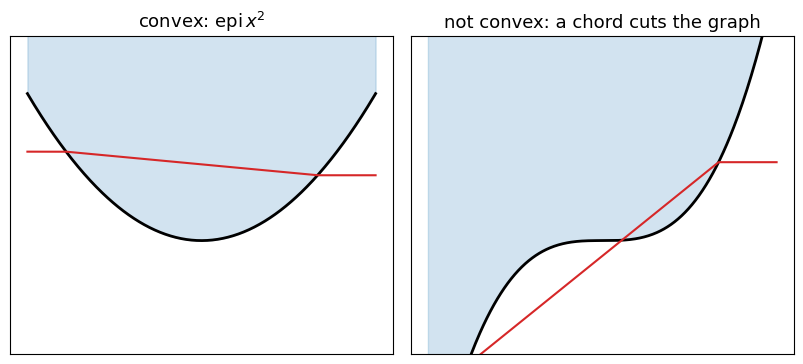

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))
x = np.linspace(-1.8, 1.8, 400)

for ax, f, title in (
    (axes[0], lambda z: z**2, r"convex: $\mathrm{epi}\,x^2$"),
    (axes[1], lambda z: z**3, r"not convex: a chord cuts the graph"),
):
    y = f(x)
    ax.plot(x, y, color="k", lw=2)
    ax.fill_between(x, y, 6, color="C0", alpha=0.2)
    xs = np.array([-1.4, 1.2])
    chord = np.interp(x, xs, f(xs))
    ax.plot(x, chord, color="C3", lw=1.5)
    ax.set_ylim(-2.5, 4.5)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
plt.show()


## Extended values, and constraints as functions

Allowing the value $+\infty$ makes constraints and objectives the same kind of object. The **indicator** of a set $C$ is

$$
\delta_C(\mathbf{x})=\begin{cases}0 & \mathbf{x}\in C,\\ +\infty & \mathbf{x}\notin C.\end{cases}
$$

- $\delta_C$ is convex if and only if $C$ is convex, because $\mathrm{epi}\,\delta_C=C\times\mathbb{R}_+$.
- Minimizing $f$ over $C$ is the unconstrained problem of minimizing $f+\delta_C$.
- A constraint you can write as a convex set becomes a convex function by this one definition.


## Examples worth memorizing

| Function | Convex on | Reason, in one line |
|---|---|---|
| Any norm $\Vert\mathbf{x}\Vert$ | $\mathbb{R}^n$ | triangle inequality is the chord, plus homogeneity |
| $\max_i(\mathbf{a}_i^\top\mathbf{x}+b_i)$ | $\mathbb{R}^n$ | max of affine functions; epigraph is a polyhedron |
| $\mathbf{x}^\top\mathbf{P}\mathbf{x}+\mathbf{q}^\top\mathbf{x}+r$ | $\mathbb{R}^n$ | convex iff $\mathbf{P}\succeq 0$ |
| $e^x$, $-\log x$, $x\log x$ | $\mathbb{R}$ or $\mathbb{R}_{++}$ | second derivative is nonnegative |
| $\lambda_{\max}(\mathbf{X})$ | $\mathbf{S}^n$ | $\sup_{\Vert\mathbf{v}\Vert_2\le 1}\mathbf{v}^\top\mathbf{X}\mathbf{v}$, a sup of linear functions |
| $-\log\det\mathbf{X}$ | $\mathbf{S}^n_{++}$ | restriction to a line reduces to $-\sum\log$ of eigenvalues |

The quadratic row is the one to be able to check in your sleep. $\mathbf{x}^\top\mathbf{P}\mathbf{x}$ with indefinite $\mathbf{P}$ is the function whose sublevel sets were the hyperboloid on the "almost, but not" slide.


## Strict and strong

Two strengthenings, used later for rates. Today only the pictures.

- **Strictly convex:** the chord inequality is strict for $\theta\in(0,1)$ and $\mathbf{x}\neq\mathbf{y}$. A strictly convex function has at most one minimizer. $e^x$ is strictly convex; a linear function is convex and not strict.
- **Strongly convex** with modulus $\mu>0$: for every $\mathbf{x},\mathbf{y}$ and $\theta\in[0,1]$,

$$
f\bigl(\theta\mathbf{x}+(1-\theta)\mathbf{y}\bigr)\le \theta f(\mathbf{x})+(1-\theta)f(\mathbf{y})-\frac{\mu}{2}\theta(1-\theta)\Vert\mathbf{x}-\mathbf{y}\Vert_2^2.
$$

Equivalently, $f-(\mu/2)\Vert\cdot\Vert_2^2$ is convex. The function bends at least as much as a parabola. $\Vert\mathbf{x}\Vert_2^2$ is strongly convex with $\mu=2$; $\Vert\mathbf{x}\Vert_1$ is convex and not strongly convex — it is flat along faces.


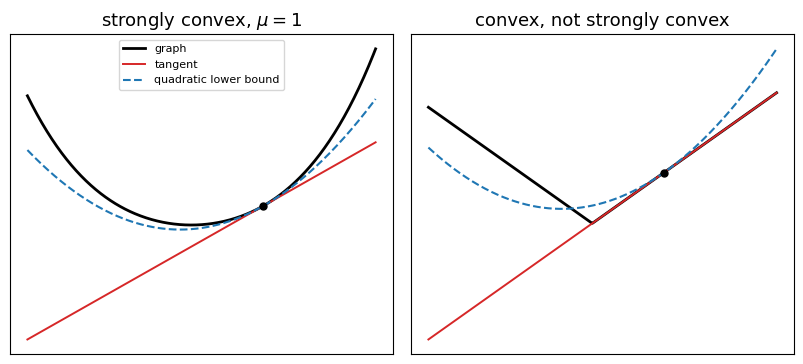

In [6]:
# Strong convexity: a quadratic lower bound at an arbitrary point.
def f_strong(z):
    return 0.5 * z**2 + 0.08 * z**4

def df_strong(z):
    return z + 0.32 * z**3

x0 = 0.7
mu = 1.0
x = np.linspace(-1.6, 1.8, 500)

def lower(f0, slope, z):
    return f0 + slope * (z - x0) + (mu / 2) * (z - x0) ** 2

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))
for ax, f, slope, title in (
    (axes[0], f_strong, df_strong(x0), r"strongly convex, $\mu=1$"),
    (axes[1], np.abs, np.sign(x0), r"convex, not strongly convex"),
):
    graph = f(x)
    tangent = f(x0) + slope * (x - x0)
    ax.plot(x, graph, color="k", lw=2, label="graph")
    ax.plot(x, tangent, color="C3", lw=1.4, label="tangent")
    ax.plot(x, lower(f(x0), slope, x), color="C0", lw=1.5, ls="--", label="quadratic lower bound")
    ax.plot(x0, f(x0), "o", color="k", ms=5)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].legend(fontsize=8, loc="upper center")
fig.tight_layout()
plt.show()


## Local minimum is global

Let $f$ be convex, let $C$ be convex, and suppose $\mathbf{x}\in C$ is a local minimizer of $f$ on $C$: some ball around $\mathbf{x}$ contains no better feasible point.

1. Take any $\mathbf{y}\in C$. The segment from $\mathbf{x}$ to $\mathbf{y}$ stays in $C$.
2. For small $\theta>0$ the point $\mathbf{z}=\theta\mathbf{y}+(1-\theta)\mathbf{x}$ lies inside the ball, so $f(\mathbf{z})\ge f(\mathbf{x})$.
3. Convexity says $f(\mathbf{z})\le \theta f(\mathbf{y})+(1-\theta)f(\mathbf{x})$.
4. The two inequalities force $f(\mathbf{y})\ge f(\mathbf{x})$.

A local minimizer cannot look downhill along any feasible segment, and convexity says every feasible point is visible along a segment. That is the argument behind the sentence from lecture 1.


## Sublevel sets are convex. The converse is false.

If $f$ is convex, every **sublevel set** $\{\mathbf{x}:f(\mathbf{x})\le \alpha\}$ is convex:

- it is a horizontal slice of the epigraph.

The converse fails.

- $f(x)=\sqrt{|x|}$ has convex sublevel sets (symmetric intervals) and is not convex: on $[0,\infty)$ it is concave.
- Functions whose sublevel sets are convex are called **quasiconvex**. They are a larger class.
- This course optimizes convex functions. "The sublevel sets look convex" is not a sufficient check.


### References — convex functions

- **Book.** Boyd and Vandenberghe, Ch. 3.1–3.2 (definition, epigraph, examples, strict and strong convexity).
- **Book.** Nesterov, *Lectures on Convex Optimization*, Ch. 2, for the strong-convexity inequality in the form used for rates.
- **Book.** Rockafellar, *Convex Analysis*, for indicators and the extended-real arithmetic.


# 4. Convexity criteria

The chord inequality quantifies over every segment. Four equivalent tests replace that quantification:

- restriction to a line;
- the tangent underestimator;
- a positive semidefinite Hessian;
- a subgradient, when there is no gradient.


## Restriction to a line

$f$ is convex if and only if every one-dimensional slice is convex: for every $\mathbf{x}$ and every direction $\mathbf{v}$,

$$
g(t)=f(\mathbf{x}+t\mathbf{v})
$$

is a convex function of $t\in\mathbb{R}$ (on its domain).

- A multivariate question becomes a family of univariate ones.
- This is how you treat $-\log\det$ and $\lambda_{\max}$.
- Restrict $\mathbf{X}\mapsto -\log\det\mathbf{X}$ to a line inside $\mathbf{S}^n_{++}$


## First order: the graph lies above every tangent

Let $f$ be differentiable on an open convex set. Then $f$ is convex if and only if, for all $\mathbf{x},\mathbf{y}$ in the set,

$$
f(\mathbf{y})\ge f(\mathbf{x})+\langle f'(\mathbf{x}),\mathbf{y}-\mathbf{x}\rangle.
$$

- The right-hand side is the affine approximation from lecture 1.
- Convexity says this approximation is a **global underestimator**, not only a local one.

**Certificate.** If $f'(\mathbf{x})=\mathbf{0}$, the inequality collapses to $f(\mathbf{y})\ge f(\mathbf{x})$ for every $\mathbf{y}$.

- A vanishing gradient is necessary for an interior minimum of a differentiable function, with or without convexity.
- Under convexity it is sufficient. That is the sense in which you can certify optimality.


## Second order: the Hessian is PSD

Let $f$ be twice differentiable on an open convex set. Then $f$ is convex if and only if

$$
f''(\mathbf{x})\succeq 0\qquad\text{for every }\mathbf{x}\text{ in the set.}
$$

- For $f(\mathbf{x})=\mathbf{x}^\top\mathbf{P}\mathbf{x}+\mathbf{q}^\top\mathbf{x}+r$ the Hessian is the constant $2\mathbf{P}$, so the test is $\mathbf{P}\succeq 0$.

**Monotonicity of the gradient**, equivalent for differentiable convex $f$:

$$
\langle f'(\mathbf{x})-f'(\mathbf{y}),\mathbf{x}-\mathbf{y}\rangle\ge 0.
$$

- Moving from $\mathbf{y}$ to $\mathbf{x}$, the gradient tilts in the same direction.
- Strong convexity makes the inequality quantitative, with an extra term $\mu\Vert\mathbf{x}-\mathbf{y}\Vert_2^2$.


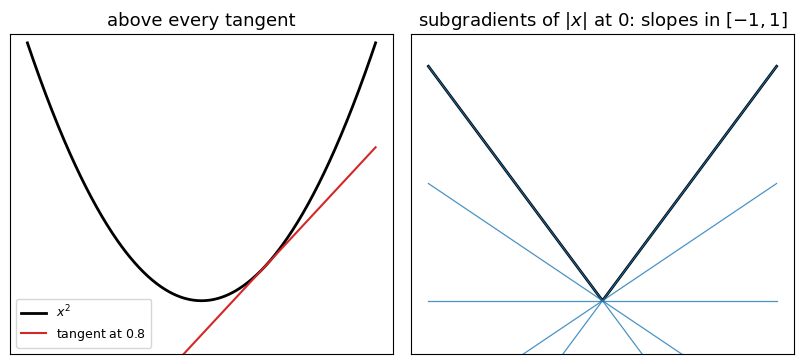

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))
x = np.linspace(-2.2, 2.2, 400)

axes[0].plot(x, x**2, color="k", lw=2, label="$x^2$")
x0 = 0.8
axes[0].plot(x, x0**2 + 2 * x0 * (x - x0), color="C3", lw=1.5, label="tangent at $0.8$")
axes[0].set_ylim(-1, 5)
axes[0].set_title("above every tangent")
axes[0].legend(fontsize=9)

axes[1].plot(x, np.abs(x), color="k", lw=2, label="$|x|$")
for slope in (-1, -0.5, 0, 0.5, 1):
    axes[1].plot(x, slope * x, color="C0", lw=0.9, alpha=0.8)
axes[1].set_ylim(-0.5, 2.5)
axes[1].set_title(r"subgradients of $|x|$ at $0$: slopes in $[-1,1]$")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()


## No gradient: subgradients

A vector $\mathbf{g}$ is a **subgradient** of $f$ at $\mathbf{x}\in\mathrm{dom}\,f$ if the same underestimator works with $\mathbf{g}$ in place of a gradient:

$$
f(\mathbf{y})\ge f(\mathbf{x})+\langle \mathbf{g},\mathbf{y}-\mathbf{x}\rangle\qquad\text{for every }\mathbf{y}.
$$

- The **subdifferential** $\partial f(\mathbf{x})$ is the set of all such $\mathbf{g}$.
- For a convex function this set is nonempty on the relative interior of the domain.
- It is a singleton $\{\,f'(\mathbf{x})\,\}$ wherever $f$ is differentiable.
- $\mathbf{x}$ minimizes a convex $f$ if and only if $\mathbf{0}\in\partial f(\mathbf{x})$. The certificate survives the kinks.

Two examples:

- $\partial |\,\cdot\,|(0)=[-1,1]$. At $x\neq 0$ it is $\{\mathrm{sign}(x)\}$.
- For a norm, $\partial\Vert\cdot\Vert(\mathbf{0})$ is the unit ball of the dual norm. Lecture 1's dual-norm formula is this fact.


## A criterion you will reuse: $\log\sum\exp$

$$
f(\mathbf{x})=\log\sum_{i=1}^n e^{x_i}.
$$

Check it with the second-order test:

1. The gradient is the softmax, $f'(\mathbf{x})=\mathbf{p}(\mathbf{x})$ with $p_i=e^{x_i}/\sum_j e^{x_j}$.
2. The Hessian is a covariance, $f''(\mathbf{x})=\mathrm{diag}(\mathbf{p})-\mathbf{p}\mathbf{p}^\top$.
3. For any $\mathbf{v}$,

$$
\mathbf{v}^\top f''(\mathbf{x})\,\mathbf{v}=\sum_i p_i v_i^2-\Bigl(\sum_i p_i v_i\Bigr)^2=\mathrm{Var}_{\mathbf{p}}(v)\ge 0.
$$

So $f''(\mathbf{x})\succeq 0$, and $f$ is convex. It is also the standard smooth upper bound on the max:

$$
\max_i x_i\le f(\mathbf{x})\le \max_i x_i+\log n.
$$

The same function appears as:

- softmax in a classifier;
- the log-partition function of an exponential family;
- a soft maximum inside a loss.


### References — criteria

- **Book.** Boyd and Vandenberghe, Ch. 3.1.3–3.1.5 (lines, first order, second order). Subgradients in 3.1 and, more fully, in the additional exercises.
- **Book.** Rockafellar, *Convex Analysis*, Part V, for the subdifferential calculus.
- **Book.** Nesterov, *Lectures on Convex Optimization*, Ch. 2.1, for the first-order characterization used as a certificate.


# 5. How to construct convex functions

Same discipline as for sets.

- Do not expand the chord inequality on the finished formula.
- Close a small family of atoms under operations that preserve convexity.


## Sums and affine precomposition

**Nonnegative combination.** If $f$ and $g$ are convex and $\alpha,\beta\ge 0$, then $\alpha f+\beta g$ is convex.

- A negative coefficient breaks it.
- The difference of two convex functions is a *DC* function. The next two slides say what that is, and why it is still useful.

**Precomposition with an affine map.** If $f$ is convex, then $\mathbf{x}\mapsto f(\mathbf{A}\mathbf{x}+\mathbf{b})$ is convex.

- Residuals $\mathbf{A}\mathbf{x}-\mathbf{b}$ fall under this rule.
- So do features, and the case where the variable is really a matrix $\sum_i x_i\mathbf{F}_i$.
- Precomposition is free. Post-composition is not — that is the composition slide.


## What a DC function is

A function is **DC** (difference of convex) when

$$
f=g-h,\qquad g\text{ and }h\text{ convex}.
$$

- The decomposition is not unique. Adding the same convex function to $g$ and to $h$ does not change $f$.
- $f$ need not be convex. The minus sign in front of $h$ is the coefficient the previous slide excludes.
- Prototype: an indefinite quadratic. Split $\mathbf{A}=\mathbf{A}_+-\mathbf{A}_-$ into the positive-eigenvalue part and the negative-eigenvalue part, both positive semidefinite. Then

$$
\mathbf{x}^\top\mathbf{A}\mathbf{x}
=\mathbf{x}^\top\mathbf{A}_+\mathbf{x}-\mathbf{x}^\top\mathbf{A}_-\mathbf{x}.
$$

- Any $C^2$ function on $\mathbb{R}^n$ admits such a split [(Hartman, 1959)](https://msp.org/pjm/1959/9-3/pjm-v9-n3-p.pdf#page=81)


## Pointwise supremum

If each $f_\alpha$ is convex, then so is

$$
f(\mathbf{x})=\sup_{\alpha\in\mathcal{A}} f_\alpha(\mathbf{x}),
$$

whenever the supremum is not identically $+\infty$.

- The epigraph of a supremum is the intersection of the epigraphs.
- An intersection of convex sets is convex.
- The family $\mathcal{A}$ may be infinite.

Three functions you already use are suprema of affine functions:

- a norm, $\Vert\mathbf{x}\Vert=\sup_{\Vert\mathbf{z}\Vert_*\le 1}\langle\mathbf{z},\mathbf{x}\rangle$, by definition of the dual norm;
- $\lambda_{\max}(\mathbf{X})=\sup_{\Vert\mathbf{v}\Vert_2\le 1}\mathbf{v}^\top\mathbf{X}\mathbf{v}$;

## Partial minimization

If $f(\mathbf{x},\mathbf{y})$ is convex in the pair $(\mathbf{x},\mathbf{y})$, then

$$
g(\mathbf{x})=\inf_{\mathbf{y}} f(\mathbf{x},\mathbf{y})
$$

is convex in $\mathbf{x}$.

- Caveat: $g$ should not be $-\infty$ everywhere, and one is careful about which $\mathbf{x}$ attain the infimum.
- Reason: the epigraph of $g$ is the projection of the epigraph of $f$, and the projection of a convex set is convex.

This is not a pointwise infimum of convex functions of $\mathbf{x}$ alone.

- $\inf_\alpha f_\alpha$ can be nonconvex.
- The picture is a $\mathrm{W}$ built as the minimum of two $\mathrm{V}$'s: each $\mathrm{V}$ is convex, and the lower envelope has a dent.


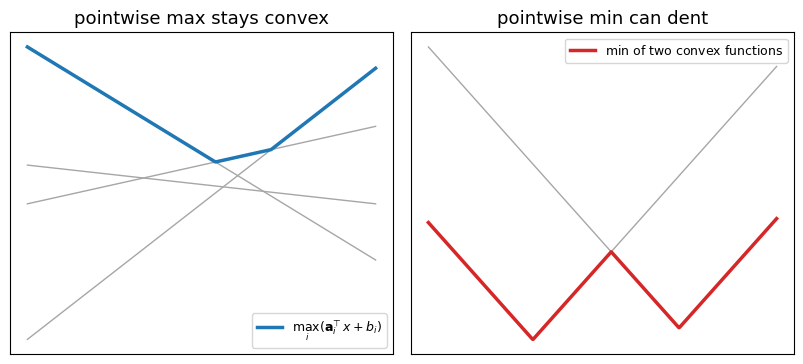

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))
x = np.linspace(-2.5, 2.5, 500)
lines = np.stack([0.4 * x + 0.2, -1.1 * x + 0.5, 1.4 * x - 0.8, -0.2 * x - 0.3], axis=0)
axes[0].plot(x, lines.T, color="0.65", lw=1)
axes[0].plot(x, lines.max(axis=0), color="C0", lw=2.5, label=r"$\max_i(\mathbf{a}_i^\top x+b_i)$")
axes[0].set_title("pointwise max stays convex")
axes[0].legend(fontsize=9)

v1 = np.abs(x + 1.0)
v2 = np.abs(x - 1.1) + 0.15
axes[1].plot(x, v1, color="0.65", lw=1)
axes[1].plot(x, v2, color="0.65", lw=1)
axes[1].plot(x, np.minimum(v1, v2), color="C3", lw=2.5, label=r"$\min$ of two convex functions")
axes[1].set_title("pointwise min can dent")
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()


## Composition

Let $h:\mathbb{R}\to\mathbb{R}$ and $g:\mathbb{R}^n\to\mathbb{R}$.

- $h$ convex and nondecreasing, $g$ convex $\Rightarrow$ $h\circ g$ convex.
- $h$ convex and nonincreasing, $g$ concave $\Rightarrow$ $h\circ g$ convex.

On several arguments:

- if $h$ is convex and nondecreasing in each argument, and each $g_i$ is convex, then $h(g_1(\mathbf{x}),\ldots,g_k(\mathbf{x}))$ is convex;
- the extended-real version needs monotonicity on the whole range, not only on $\mathbb{R}$;
- this is the rule DCP will enforce **syntactically**.

The monotonicity hypothesis is doing the work. Two compositions, one legal and one not:

- $h(u)=e^{-u}$ is convex and *decreasing*, $g(x)=x^2$ is convex, so the rule does not apply. The composition $e^{-x^2}$ is not convex.
- $\mathrm{square}(\mathrm{square}(x))=x^4$ is allowed: $u\mapsto u^2$ is convex and nondecreasing on $\mathbb{R}_+$, and $x^2\ge 0$.


## Perspective of a function

For $t>0$, the **perspective** of $f$ is $(\mathbf{x},t)\mapsto t\,f(\mathbf{x}/t)$.

This is the set fact from section 2, applied to the epigraph.

- $(\mathbf{x},t,s)$ lies in the epigraph iff $t>0$ and $s/t\ge f(\mathbf{x}/t)$.
- That is the same as $t>0$ and $(\mathbf{x}/t,\ s/t)\in\mathrm{epi}\,f$.
- So the epigraph is the preimage of $\mathrm{epi}\,f$ under $(\mathbf{x},s,t)\mapsto(\mathbf{x}/t,\ s/t)$.
- Section 2: the preimage of a convex set under the perspective map is convex. Hence if $f$ is convex, so is its perspective.

Two instances you will meet as atoms, not as new proofs:

- $f(u)=u^2$ gives **quadratic-over-linear**, $\Vert\mathbf{x}\Vert_2^2/t$ for $t>0$. CVXPY atom: `quad_over_lin`.
- $f(u)=u\log u$ gives the relative-entropy perspective $x\log(x/t)$. CVXPY atoms: `entr`, `rel_entr`.


### References — constructions

- **Book.** Boyd and Vandenberghe, Ch. 3.2 (operations that preserve convexity of functions), including the composition rules and the perspective.
- **Book.** Rockafellar, *Convex Analysis*, for the conjugate and for partial minimization with the right domain hypotheses.
- **DC functions.** P. Hartman, *On functions representable as a difference of convex functions*, *Pacific J. Math.* 1959. H. A. Le Thi and T. Pham Dinh, [*DC programming and DCA: thirty years of developments*](https://doi.org/10.1007/s10107-018-1235-y), *Math. Program.* 2018.
- **Paper.** M. Grant, S. Boyd, Y. Ye, [*Disciplined convex programming*](https://web.stanford.edu/~boyd/papers/pdf/disc_cvx_prog.pdf) — the composition rules on the previous slide, turned into a grammar. That is section 6.


# 6. What DCP is

Disciplined convex programming is a grammar for the operations of section 5.

- If an expression parses, it is convex by construction, and **a solver can turn it into a cone program**.
- If it does not parse, the expression may still be convex.


## A grammar, not a convexity test

Every atom (`square`, `exp`, `norm`, `log_sum_exp`, `log_det`, …) declares three attributes:

- **curvature** — convex, concave, or affine;
- **sign** — nonnegative, nonpositive, or unknown;
- **monotonicity** — increasing, decreasing, or neither, in each argument.

An expression is **DCP** when every composition in its tree matches the composition rules, using only those declared attributes.

- CVXPY, CVX, and Convex.jl implement this check.
- The check is syntactic: it does not look at your Hessian, and it does not try to prove a general formula.

The canonical problem the grammar accepts is

$$
\begin{aligned}
\mathrm{minimize}&\quad f_0(\mathbf{x})\\
\mathrm{subject\ to}&\quad f_i(\mathbf{x})\le 0,\quad i=1,\ldots,m,\\
&\quad \mathbf{A}\mathbf{x}=\mathbf{b},
\end{aligned}
$$

with each $f_i$ DCP-convex and the equalities affine.

- Maximizing a convex function is rejected.
- A concave function on the left of $\le$ is rejected.
- Swap the direction, or negate the function, and the same mathematics becomes legal.


## The trap: convex, and still illegal

$\log\sum_i e^{x_i}$ is convex — we computed the Hessian. Written as `log(sum(exp(x)))` it is not DCP.

- `log` is concave and increasing.
- `sum(exp(x))` is convex.
- Concave-increasing of convex is not a legal rule, so the product of the attributes is not "convex".
- CVXPY reports the curvature as quasiconvex and refuses the problem.

The atom `log_sum_exp` is the same function with the curvature declared directly. Use the atom.

The grammar can see some sign information:

- `square(square(x))` is legal, because `square` is increasing on the nonnegative reals and `square(x)` is nonnegative;
- it cannot see an algebraic identity you have not told it.


In [9]:
x = cp.Variable(3)
t = cp.Variable(pos=True)
A = rng.normal(size=(5, 3))
b = np.ones(5)

rows = [
    ("sum_squares(Ax-b) + norm(x,1)", cp.sum_squares(A @ x - b) + cp.norm(x, 1)),
    ("log(sum(exp(x)))", cp.log(cp.sum(cp.exp(x)))),
    ("log_sum_exp(x)", cp.log_sum_exp(x)),
    ("square(square(x))", cp.square(cp.square(x))),
    ("quad_over_lin(x, t)", cp.quad_over_lin(x, t)),
    ("-log_det(X) on a PSD variable", -cp.log_det(cp.Variable((3, 3), PSD=True))),
]

print(f"{'expression':<32}  {'curvature':<12}  DCP")
for name, expr in rows:
    print(f"{name:<32}  {expr.curvature:<12}  {expr.is_dcp()}")

print()
print("maximize sum_squares(x) is DCP:", cp.Problem(cp.Maximize(cp.sum_squares(x))).is_dcp())
print(
    "minimize sum_squares s.t. log_sum_exp <= 1 is DCP:",
    cp.Problem(cp.Minimize(cp.sum_squares(x)), [cp.log_sum_exp(x) <= 1]).is_dcp(),
)


expression                        curvature     DCP
sum_squares(Ax-b) + norm(x,1)     CONVEX        True
log(sum(exp(x)))                  QUASICONVEX   False
log_sum_exp(x)                    CONVEX        True
square(square(x))                 CONVEX        True
quad_over_lin(x, t)               CONVEX        True
-log_det(X) on a PSD variable     CONVEX        True

maximize sum_squares(x) is DCP: False
minimize sum_squares s.t. log_sum_exp <= 1 is DCP: True


### References — DCP

- **Paper.** M. Grant, S. Boyd, Y. Ye, [*Disciplined convex programming*](https://web.stanford.edu/~boyd/papers/pdf/disc_cvx_prog.pdf), 2006.
- **Software.** S. Diamond and S. Boyd, [*CVXPY*](https://arxiv.org/abs/1603.00943), *JMLR* 2016; the [DCP tutorial](https://www.cvxpy.org/tutorial/dcp/index.html) lists the atoms and the composition rules the checker applies.


# 7. Modeling with convex functions

Two constructions from this lecture, used as models. Each one is convex because of a rule we already have:

- a robust constraint, by a supremum over an ellipsoid;
- a stand-in for rank, by a norm.


## An ellipsoidal robust constraint

A linear constraint $\mathbf{a}^\top\mathbf{x}\le b$ trusts $\mathbf{a}$. Robust optimization refuses that. Let the data range over an ellipsoid

$$
\mathbf{a}=\bar{\mathbf{a}}+\mathbf{P}\mathbf{u},\qquad \Vert\mathbf{u}\Vert_2\le 1,
$$

and demand the constraint for every such $\mathbf{a}$:

$$
\sup_{\Vert\mathbf{u}\Vert_2\le 1}(\bar{\mathbf{a}}+\mathbf{P}\mathbf{u})^\top\mathbf{x}\le b.
$$

Why the left-hand side is a convex function of $\mathbf{x}$:

- for each fixed $\mathbf{u}$ it is affine in $\mathbf{x}$;
- a supremum of affine functions is convex.

The supremum collapses, in three steps:

1. $(\bar{\mathbf{a}}+\mathbf{P}\mathbf{u})^\top\mathbf{x}=\bar{\mathbf{a}}^\top\mathbf{x}+\mathbf{u}^\top(\mathbf{P}^\top\mathbf{x})$.
2. The support function of the Euclidean ball is the Euclidean norm: $\sup_{\Vert\mathbf{u}\Vert_2\le 1}\mathbf{u}^\top\mathbf{v}=\Vert\mathbf{v}\Vert_2$.
3. With $\mathbf{v}=\mathbf{P}^\top\mathbf{x}$ the robust constraint is the second-order cone inequality

$$
\bar{\mathbf{a}}^\top\mathbf{x}+\Vert\mathbf{P}^\top\mathbf{x}\Vert_2\le b.
$$

The nominal problem is a linear program. The robust counterpart is a different convex problem. Convexity survives because the worst case over a convex uncertainty set is a support function, and the support function of this ellipsoid is a norm.


                        objective   worst a1   worst a2
nominal LP                  1.600      1.468      1.468
robust SOCP                 1.090      1.000      1.000


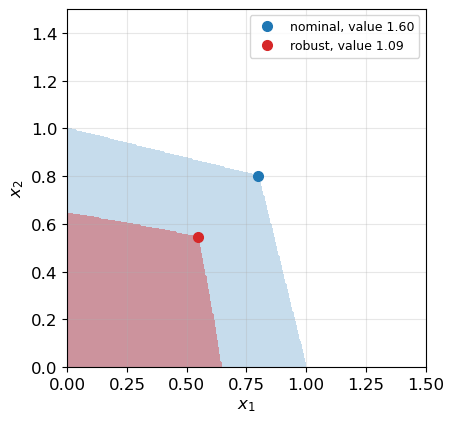

In [10]:
# Nominal LP versus its ellipsoidal robust counterpart (an SOCP).
a1 = np.array([1.0, 0.25])
a2 = np.array([0.25, 1.0])
P1 = np.diag([0.55, 0.20])
P2 = np.diag([0.20, 0.55])
c = np.array([1.0, 1.0])

def solve(robust):
    x = cp.Variable(2)
    constraints = [x >= 0]
    for a_bar, P in ((a1, P1), (a2, P2)):
        margin = cp.norm(P.T @ x, 2) if robust else 0
        constraints.append(a_bar @ x + margin <= 1)
    problem = cp.Problem(cp.Maximize(c @ x), constraints)
    problem.solve(solver=cp.CLARABEL)
    return x.value

x_nom = solve(robust=False)
x_rob = solve(robust=True)

def worst(x_hat, a_bar, P):
    return a_bar @ x_hat + np.linalg.norm(P.T @ x_hat)

print(f"{'':22} {'objective':>10} {'worst a1':>10} {'worst a2':>10}")
for name, x_hat in (("nominal LP", x_nom), ("robust SOCP", x_rob)):
    print(
        f"{name:22} {c @ x_hat:10.3f} "
        f"{worst(x_hat, a1, P1):10.3f} {worst(x_hat, a2, P2):10.3f}"
    )

g = np.linspace(0, 1.55, 320)
X1, X2 = np.meshgrid(g, g)
def margin(a_bar, P):
    return X1 * a_bar[0] + X2 * a_bar[1] + np.sqrt((P[0, 0] * X1) ** 2 + (P[1, 1] * X2) ** 2)

nominal = (X1 * a1[0] + X2 * a1[1] <= 1) & (X1 * a2[0] + X2 * a2[1] <= 1)
robust = (margin(a1, P1) <= 1) & (margin(a2, P2) <= 1)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.contourf(X1, X2, nominal.astype(float), levels=[0.5, 1.5], colors=["C0"], alpha=0.25)
ax.contourf(X1, X2, robust.astype(float), levels=[0.5, 1.5], colors=["C3"], alpha=0.4)
ax.plot(*x_nom, "o", color="C0", ms=7, label=f"nominal, value {c @ x_nom:.2f}")
ax.plot(*x_rob, "o", color="C3", ms=7, label=f"robust, value {c @ x_rob:.2f}")
ax.set_aspect("equal")
ax.set_xlim(0, 1.5)
ax.set_ylim(0, 1.5)
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()


## Nuclear norm as a convex stand-in for rank

$\mathrm{rank}$ is not convex: $\{\mathbf{X}:\mathrm{rank}\le k\}$ fails the segment test.

- On the spectral-norm ball $\{\mathbf{X}:\Vert\mathbf{X}\Vert_{2\to 2}\le 1\}$, the convex envelope of rank — the largest convex underestimator — is the **nuclear norm** $\Vert\mathbf{X}\Vert_*=\sum_i\sigma_i(\mathbf{X})$.
- Lecture 1 recorded that $\Vert\cdot\Vert_*$ and $\Vert\cdot\Vert_{2\to 2}$ are dual. This is the modeling consequence.

**Matrix completion.** Observe a subset $\Omega$ of the entries of a low-rank matrix $\mathbf{M}$ and solve

$$
\begin{aligned}
\mathrm{minimize}&\quad \Vert\mathbf{X}\Vert_*\\
\mathrm{subject\ to}&\quad X_{ij}=M_{ij},\quad (i,j)\in\Omega.
\end{aligned}
$$

- The constraint is affine.
- The objective is a norm, hence convex.
- Exact recovery has hypotheses (incoherence, enough random entries). The claim on this slide is only the convexity.


In [11]:
n, r, frac = 16, 2, 0.55
local = np.random.default_rng(2)
factors_left = local.normal(size=(n, r))
factors_right = local.normal(size=(r, n))
M = factors_left @ factors_right
mask = local.random((n, n)) < frac

X = cp.Variable((n, n))
problem = cp.Problem(cp.Minimize(cp.norm(X, "nuc")), [X[mask] == M[mask]])
problem.solve(solver=cp.CLARABEL)
rel = np.linalg.norm(X.value - M) / np.linalg.norm(M)
print(f"observed {100 * frac:.0f}% of entries of a rank-{r} matrix")
print(f"status {problem.status}")
print(f"relative Frobenius error {rel:.3e}")
print(f"nuclear norm of M {np.linalg.svd(M, compute_uv=False).sum():.3f}")
print(f"nuclear norm of X {np.linalg.svd(X.value, compute_uv=False).sum():.3f}")


observed 55% of entries of a rank-2 matrix
status optimal
relative Frobenius error 1.121e-07
nuclear norm of M 30.186
nuclear norm of X 30.186


## Takeaway

Check convexity at the leaves, then use the calculus.

1. A set is convex when segments stay inside. Build it by intersection, affine image, affine preimage, product, Minkowski sum, and perspective.
2. A function is convex when its epigraph is a convex set. The chord, the tangent underestimator, a PSD Hessian, and $0\in\partial f(\mathbf{x})$ are the same fact in four languages.
3. Build functions by nonnegative combination, affine precomposition, pointwise supremum, partial minimization, legal composition, and perspective.
4. DCP is that list, enforced by a parser. A rejection means "rewrite with the right atom", not "the mathematics is nonconvex".
5. The models in this section — ellipsoidal robust constraints, nuclear norm — are those operations, not special cases.


### References — the two models

- **Robust optimization.** A. Ben-Tal and A. Nemirovski, [*Robust convex optimization*](https://doi.org/10.1287/moor.23.4.769), *Math. Oper. Res.* 1998. D. Bertsimas, D. B. Brown, C. Caramanis, [*Theory and applications of robust optimization*](https://doi.org/10.1137/080734510), *SIAM Review* 2011.
- **Nuclear norm.** M. Fazel, H. Hindi, S. Boyd, [*A rank minimization heuristic with application to minimum order system approximation*](https://web.stanford.edu/~boyd/papers/rank_min.html), ACC 2001. E. Candès and B. Recht, [*Exact matrix completion via convex optimization*](https://arxiv.org/abs/0805.4471), *Found. Comput. Math.* 2009.
